# *Eva Foundation Model — IMMUcan Benchmark Pipeline v7 (Final)*

Cell 1: Environment Setup

In [ ]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.3'
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-12.3/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import sys
import torch
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import json
from tqdm import tqdm
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

sys.path.insert(0, '/home/juliaoesterle/.ssh/spCellEval/src/clustering_methods/')
from greedy_f1_utils import greedy_f1_score

sns.set_style("whitegrid")

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
device = "cuda:1" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

 Cell 2: Load Eva Model

In [ ]:
sys.path.insert(0, '/home/juliaoesterle/eva/project')
from omegaconf import OmegaConf
from Eva.utils import load_from_hf

os.chdir("/home/juliaoesterle/eva/project")

conf  = OmegaConf.load("config.yaml")
model = load_from_hf(repo_id="yandrewl/Eva", conf=conf, device=device)
model.eval()
print("Model loaded on:", next(model.parameters()).device)

Cell 3: Define Markers

In [ ]:
biomarkers_all = [
    "MPO", "HistoneH3", "SMA", "CD16", "CD38", "HLADR", "CD27", "CD15",
    "CD45RA", "CD163", "B2M", "CD20", "CD68", "Ido1", "CD3", "LAG3",
    "CD11c", "PD1", "PDGFRb", "CD7", "GrzB", "PDL1", "TCF7", "CD45RO",
    "FOXP3", "ICOS", "CD8a", "CarbonicAnhydrase", "CD33", "Ki67",
    "VISTA", "CD40", "CD4", "CD14", "Ecad", "CD303", "CD206",
    "cleavedPARP", "DNA1", "DNA2"
]

dna_channels  = {'DNA1', 'DNA2', 'HistoneH3'}
clean_indices = [i for i, m in enumerate(biomarkers_all) if m not in dna_channels]
biomarkers    = [m for m in biomarkers_all if m not in dna_channels]
print(f"Using {len(biomarkers)} markers (excluded: {dna_channels})")

Cell 4: Paths & Constants

In [ ]:
NPZ_DIR    = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/data/images/"
MASK_DIR   = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/segmentation/"
LABELS_DIR = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/cells2labels/"
FOLDS_FILE = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/folds.json"
SDS_BASE   = "/home/juliaoesterle/.ssh/spCellEval/"
OUTPUT_DIR = "/home/juliaoesterle/eva/project/figures/pipeline_v7/"
CACHE_DIR  = "/home/juliaoesterle/eva/project/figures/pipeline_v7/cache_bbox/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)

label_map_df = pd.read_csv(
    "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/labels_cell_type.csv"
)
label_map = dict(zip(label_map_df['label'], label_map_df['phenotype']))

PATCH_SIZE = 224   # Eva fixed input — hard-coded assertion in model
BATCH_SIZE = 16    # cells per forward pass
N_FOLDS    = 5
LEIDEN_RES = 2.0   

Cell 5: Load Folds 

In [ ]:
with open(FOLDS_FILE) as f:
    folds_data = json.load(f)

folds = [{'train': folds_data[f'fold_{i}_train_set'],
           'test':  folds_data[f'fold_{i}_test_set']}
         for i in range(N_FOLDS)]

all_images = sorted(set(
    img for fold in folds for split in ['train', 'test'] for img in fold[split]
))
print(f"Total images: {len(all_images)}")
for i, fold in enumerate(folds):
    print(f"  Fold {i}: {len(fold['train'])} train | {len(fold['test'])} test")

Cell 6: Ground Truth Validation

In [ ]:
print("\nValidating ground truth mapping on first image...")
test_img_name = all_images[0]
test_mask     = tifffile.imread(MASK_DIR + test_img_name + '.tiff')
with open(LABELS_DIR + test_img_name + '.txt') as f:
    test_labels = [int(line.strip()) for line in f.readlines()]

cell_ids_test = np.unique(test_mask); cell_ids_test = cell_ids_test[cell_ids_test > 0]
unknown_count = sum(1 for cid in cell_ids_test
                    if cid-1 < len(test_labels) and test_labels[cid-1] == -1)
valid_count   = sum(1 for cid in cell_ids_test
                    if cid-1 < len(test_labels) and test_labels[cid-1] != -1)
print(f"  Image: {test_img_name}")
print(f"  Valid labels (0-13): {valid_count}")
print(f"  Unknown (-1): {unknown_count}  ← excluded from train/eval")
print(f"  Label map: {label_map}")
print("Mapping validated ✓\n")

Cell 7: Core Functions

In [ ]:
def get_label(cell_id, cell_labels, label_map):
    """
    Validated ground truth lookup:
      cell_labels[cell_id - 1] → raw label
      -1 = Unknown (no annotation) → excluded from train/eval
      0-13 = valid phenotype class
    """
    idx = cell_id - 1
    if idx >= len(cell_labels):
        return 'Unknown'
    raw = cell_labels[idx]
    if raw == -1:
        return 'Unknown'
    return label_map.get(raw, 'Unknown')


def get_bbox_patch(img, ys, xs, patch_size=224):
    """
    Crop the EXACT bounding box of the cell from its segmentation mask pixels,
    then symmetrically zero-pad to patch_size × patch_size.

    Unlike v6's fixed crops (12×12 or 32×32), this captures the full cell
    regardless of shape or size — small cells get more padding, large cells
    get less. Follows PyTorch vision bounding box convention.

    Returns:
        patch: (patch_size, patch_size, C) zero-padded array
        crop_h: actual bounding box height in pixels
        crop_w: actual bounding box width in pixels
    """
    H, W = img.shape[:2]

    # Tight bounding box from actual mask pixels
    y_min, y_max = int(ys.min()), int(ys.max())
    x_min, x_max = int(xs.min()), int(xs.max())

    # Crop exact bounding box — (cell_h, cell_w, C)
    crop = img[y_min:y_max+1, x_min:x_max+1, :]
    crop_h, crop_w = crop.shape[:2]

    # Safety: if cell bounding box exceeds 224px (very rare), center-crop
    if crop_h > patch_size or crop_w > patch_size:
        cy, cx = crop_h // 2, crop_w // 2
        half   = patch_size // 2
        crop   = crop[max(0,cy-half):cy+half, max(0,cx-half):cx+half, :]
        crop_h, crop_w = crop.shape[:2]

    # Symmetric zero-padding to patch_size × patch_size
    pad_h = patch_size - crop_h
    pad_w = patch_size - crop_w
    patch = np.pad(crop, (
        (pad_h // 2, pad_h - pad_h // 2),
        (pad_w // 2, pad_w - pad_w // 2),
        (0, 0)
    ))

    return patch, crop_h, crop_w


def extract_features_batch(patches, model, biomarkers, device):
    """
    Batched Eva forward pass on 224×224 patches.
    Returns CLS token as cell feature: (N, D=768)
    KEY: .contiguous() required after .permute() — Eva uses .view() internally.
    """
    batch       = np.stack(patches)                                    # (N, 224, 224, C)
    batch_t     = torch.from_numpy(batch).to(device)
    batch_input = batch_t.permute(0, 3, 1, 2).contiguous()            # (N, C, 224, 224)
    batch_bms   = [biomarkers] * len(patches)

    with torch.no_grad():
        token_out, _ = model.model.forward_encoder(batch_input, batch_bms)

    # token_out: (N, 1, 785, 768) — CLS token at index 0
    return token_out[:, 0, 0, :].contiguous().cpu().numpy()            # (N, 768)


Cell 8: Feature Extraction — Adaptive Bounding Box

In [ ]:
print("Extracting features — adaptive bounding box → 224×224 padded")
print("="*60)

img_feature_store = {}   # img_name → (feats_arr, labels_list, cell_ids_list)
bbox_stats_list   = []   # per-cell bbox size log

for img_name in tqdm(all_images, desc="bbox extraction"):
    cache_feat = CACHE_DIR + f"{img_name}_feat.npy"
    cache_meta = CACHE_DIR + f"{img_name}_meta.csv"

    # Load from cache if available (crash-safe)
    if os.path.exists(cache_feat) and os.path.exists(cache_meta):
        feats = np.load(cache_feat)
        meta  = pd.read_csv(cache_meta)
        img_feature_store[img_name] = (
            feats, meta['label'].tolist(), meta['cell_id'].tolist()
        )
        bbox_stats_list.extend(meta[['cell_id', 'bbox_h', 'bbox_w', 'n_pixels']]
                               .assign(image_id=img_name)
                               .to_dict('records'))
        continue

    npz_file   = NPZ_DIR    + img_name + '.npz'
    mask_file  = MASK_DIR   + img_name + '.tiff'
    label_file = LABELS_DIR + img_name + '.txt'
    if not all(os.path.exists(f) for f in [npz_file, mask_file, label_file]):
        print(f"  Skipping {img_name} — missing files")
        continue

    # Load and preprocess image
    img = np.load(npz_file)['data'].astype(np.float32)
    img = img[clean_indices]
    img = img / (img.max() + 1e-8)
    img = img.transpose(1, 2, 0)  # (H, W, C)

    # Load mask and labels
    mask = tifffile.imread(mask_file)
    with open(label_file) as lf:
        cell_labels = [int(line.strip()) for line in lf.readlines()]

    cell_ids_unique = np.unique(mask)
    cell_ids_unique = cell_ids_unique[cell_ids_unique > 0]

    patches_buf, labels_buf, cell_ids_buf, bbox_buf = [], [], [], []

    for cell_id in cell_ids_unique:
        label  = get_label(int(cell_id), cell_labels, label_map)
        ys, xs = np.where(mask == cell_id)
        patch, bbox_h, bbox_w = get_bbox_patch(img, ys, xs, PATCH_SIZE)
        patches_buf.append(patch)
        labels_buf.append(label)
        cell_ids_buf.append(int(cell_id))
        bbox_buf.append({'image_id': img_name, 'cell_id': int(cell_id),
                         'bbox_h': bbox_h, 'bbox_w': bbox_w, 'n_pixels': len(ys)})

    # Batched forward passes
    all_feats = []
    for i in range(0, len(patches_buf), BATCH_SIZE):
        batch_feats = extract_features_batch(
            patches_buf[i:i+BATCH_SIZE], model, biomarkers, device
        )
        all_feats.extend(batch_feats)
        torch.cuda.empty_cache()

    feats_arr = np.array(all_feats)

    # Cache per image
    np.save(cache_feat, feats_arr)
    cache_meta_df = pd.DataFrame({
        'image_id': [img_name] * len(cell_ids_buf),
        'cell_id':  cell_ids_buf,
        'label':    labels_buf,
        'bbox_h':   [b['bbox_h']   for b in bbox_buf],
        'bbox_w':   [b['bbox_w']   for b in bbox_buf],
        'n_pixels': [b['n_pixels'] for b in bbox_buf],
    })
    cache_meta_df.to_csv(cache_meta, index=False)

    img_feature_store[img_name] = (feats_arr, labels_buf, cell_ids_buf)
    bbox_stats_list.extend(bbox_buf)

# Combine all images
all_feats_list, all_labels_list, all_cell_ids_list, all_img_ids_list = [], [], [], []
for img_name, (feats, labels, cell_ids) in img_feature_store.items():
    all_feats_list.extend(feats)
    all_labels_list.extend(labels)
    all_cell_ids_list.extend(cell_ids)
    all_img_ids_list.extend([img_name] * len(cell_ids))

all_feats_arr = np.array(all_feats_list)
feat_cols     = [f"emb_{i}" for i in range(all_feats_arr.shape[1])]

# Save combined features + metadata
np.save(OUTPUT_DIR + "all_cell_features_bbox.npy", all_feats_arr)
metadata_all = pd.DataFrame({
    'image_id': all_img_ids_list,
    'cell_id':  all_cell_ids_list,
    'label':    all_labels_list,
})
metadata_all.to_csv(OUTPUT_DIR + "all_cell_metadata_bbox.csv", index=False)

# Save bbox size statistics
bbox_df = pd.DataFrame(bbox_stats_list)
bbox_df.to_csv(OUTPUT_DIR + "bbox_size_stats.csv", index=False)

print(f"\nDone! {len(all_feats_arr):,} cells extracted")
print(f"Bbox height — mean: {bbox_df['bbox_h'].mean():.1f} ± {bbox_df['bbox_h'].std():.1f} px")
print(f"Bbox width  — mean: {bbox_df['bbox_w'].mean():.1f} ± {bbox_df['bbox_w'].std():.1f} px")
print(f"Cell area   — mean: {bbox_df['n_pixels'].mean():.1f} ± {bbox_df['n_pixels'].std():.1f} px²")
print(pd.Series(all_labels_list).value_counts())

Cell 9: 5-Fold Cross-Validation — Random Forest

In [ ]:
print("\n5-Fold CV — Random Forest on adaptive bbox embeddings")
print("="*60)

fold_reports   = {}
all_fold_preds = []

for fold_idx in range(N_FOLDS):
    print(f"\n── Fold {fold_idx} ──────────────────────")
    train_images = folds[fold_idx]['train']
    test_images  = folds[fold_idx]['test']

    # Collect train cells — exclude Unknown
    X_train, y_train = [], []
    for img_name in train_images:
        if img_name not in img_feature_store:
            continue
        feats, labels, _ = img_feature_store[img_name]
        mask_known = np.array(labels) != 'Unknown'
        X_train.extend(np.array(feats)[mask_known])
        y_train.extend(np.array(labels)[mask_known])

    X_train = np.array(X_train)
    y_train = np.array(y_train)
    print(f"  Train: {len(X_train):,} cells | {len(train_images)} images")

    clf = RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced'
    )
    clf.fit(X_train, y_train)

    # Predict test cells
    fold_preds = []
    for img_name in test_images:
        if img_name not in img_feature_store:
            continue
        feats, labels, cell_ids = img_feature_store[img_name]
        feats = np.array(feats)
        y_pred  = clf.predict(feats)
        y_proba = clf.predict_proba(feats)

        for cell_id, true_label, pred_label, proba in zip(
            cell_ids, labels, y_pred, y_proba
        ):
            fold_preds.append({
                'image_id':            img_name,
                'cell_id':             cell_id,
                'fold':                fold_idx,
                'true_phenotype':      true_label,
                'predicted_phenotype': pred_label,
                'confidence':          proba.max(),
            })

    fold_df = pd.DataFrame(fold_preds)
    fold_df.to_csv(OUTPUT_DIR + f"Prediction_fold_{fold_idx}_bbox.csv", index=False)
    print(f"  Test:  {len(fold_df):,} cells | {len(test_images)} images")
    print(f"  Saved: Prediction_fold_{fold_idx}_bbox.csv")

    known  = fold_df[fold_df['true_phenotype'] != 'Unknown']
    report = classification_report(
        known['true_phenotype'], known['predicted_phenotype'],
        output_dict=True, zero_division=0
    )
    fold_reports[fold_idx] = report
    print(f"  Accuracy: {report['accuracy']:.3f} | Macro F1: {report['macro avg']['f1-score']:.3f}")
    all_fold_preds.append(fold_df)

all_preds_df = pd.concat(all_fold_preds, ignore_index=True)
all_preds_df.to_csv(OUTPUT_DIR + "Prediction_all_folds_bbox.csv", index=False)

fold_summary = pd.DataFrame({
    'fold':        range(N_FOLDS),
    'accuracy':    [fold_reports[i]['accuracy']                 for i in range(N_FOLDS)],
    'macro_f1':    [fold_reports[i]['macro avg']['f1-score']    for i in range(N_FOLDS)],
    'weighted_f1': [fold_reports[i]['weighted avg']['f1-score'] for i in range(N_FOLDS)],
})
fold_summary.to_csv(OUTPUT_DIR + "fold_summary_bbox.csv", index=False)

print(f"\nRandom Forest Results (bbox):")
print(f"  Accuracy:    {fold_summary['accuracy'].mean():.3f} ± {fold_summary['accuracy'].std():.3f}")
print(f"  Macro F1:    {fold_summary['macro_f1'].mean():.3f} ± {fold_summary['macro_f1'].std():.3f}")
print(f"  Weighted F1: {fold_summary['weighted_f1'].mean():.3f} ± {fold_summary['weighted_f1'].std():.3f}")


Cell 10: Leiden Clustering

In [ ]:
print(f"\nRunning Leiden (res={LEIDEN_RES}, igraph backend)...")

known_mask  = np.array(all_labels_list) != 'Unknown'
X_known     = all_feats_arr[known_mask]
y_known     = np.array(all_labels_list)[known_mask]
meta_known  = metadata_all[known_mask].reset_index(drop=True)

adata = sc.AnnData(X=X_known)
adata.obs['true_label'] = pd.Categorical(y_known)
adata.obs['image_id']   = meta_known['image_id'].values
adata.obs['cell_id']    = meta_known['cell_id'].values.astype(str)

MAX_CELLS = 50000
if len(adata) > MAX_CELLS:
    print(f"  Subsampling to {MAX_CELLS:,} cells...")
    sc.pp.subsample(adata, n_obs=MAX_CELLS, random_state=42)

print("  Computing neighbours...")
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')
print("  Running Leiden (igraph)...")
sc.tl.leiden(
    adata,
    resolution=LEIDEN_RES,
    random_state=42,
    flavor='igraph',        # FIX: faster igraph backend
    n_iterations=2,         # FIX: required for igraph
    directed=False          # FIX: required for igraph
)
n_clusters = adata.obs['leiden'].nunique()
print(f"  Found {n_clusters} clusters")
print("  Computing UMAP...")
sc.tl.umap(adata, random_state=42)

leiden_df = pd.DataFrame({
    'image_id':       adata.obs['image_id'].values,
    'cell_id':        adata.obs['cell_id'].values,
    'true_label':     adata.obs['true_label'].values,
    'leiden_cluster': adata.obs['leiden'].values,
    'umap_1':         adata.obsm['X_umap'][:, 0],
    'umap_2':         adata.obsm['X_umap'][:, 1],
})
leiden_df.to_csv(OUTPUT_DIR + f"leiden_clusters_bbox_res{LEIDEN_RES}.csv", index=False)
print(f"  Saved leiden_clusters_bbox_res{LEIDEN_RES}.csv")


Cell 11: Greedy F1 on Leiden Clusters

In [ ]:
print("\nRunning Greedy F1 on Leiden clusters...")

greedy_result = greedy_f1_score(
    df=leiden_df,
    true_label_col='true_label',
    predicted_cluster_col='leiden_cluster',
    tie_strategy='first'
)

print(f"\nBounding Box — Leiden Greedy F1 (res={LEIDEN_RES}):")
print(f"  Accuracy:    {greedy_result['accuracy']:.3f}")
print(f"  Macro F1:    {greedy_result['f1_macro']:.3f}")
print(f"  Weighted F1: {greedy_result['f1_weighted']:.3f}")
print(f"  ARI:         {greedy_result['ari']:.3f}")
print(f"  NMI:         {greedy_result['nmi']:.3f}")
print(f"  MCC:         {greedy_result['mcc']:.3f}")
print(f"  Kappa:       {greedy_result['kappa']:.3f}")
print("\n  Cluster → Label mapping:")
for cluster, label in sorted(greedy_result['mapping'].items(), key=lambda x: int(x[0])):
    print(f"    Cluster {cluster:>3} → {label}")

pd.DataFrame([{
    'approach':    'EVA_bbox',
    'leiden_res':  LEIDEN_RES,
    'n_clusters':  n_clusters,
    'accuracy':    greedy_result['accuracy'],
    'f1_macro':    greedy_result['f1_macro'],
    'f1_weighted': greedy_result['f1_weighted'],
    'ari':         greedy_result['ari'],
    'nmi':         greedy_result['nmi'],
    'mcc':         greedy_result['mcc'],
    'kappa':       greedy_result['kappa'],
}]).to_csv(OUTPUT_DIR + "greedy_f1_metrics_bbox.csv", index=False)


Cell 12: Assign Leiden Clusters to ALL Cells via KNN

In [ ]:
print("\nAssigning Leiden clusters to all cells via KNN...")

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(adata.X, adata.obs['leiden'].values)
all_leiden_clusters = knn.predict(all_feats_arr)

metadata_all = metadata_all.copy()
metadata_all['leiden_cluster']   = all_leiden_clusters
metadata_all['leiden_predicted'] = [
    greedy_result['mapping'].get(str(c), greedy_result['mapping'].get(c, 'unmapped'))
    for c in all_leiden_clusters
]
print(f"  Done — {len(metadata_all):,} cells assigned")

Cell 13: Save spCellEval Folder Structure

In [ ]:
print("\nSaving in spCellEval folder structure...")
print(f"  Base: {SDS_BASE}")

# Build a lookup: (image_id, cell_id) → row index in all_feats_arr
# for fast embedding retrieval — avoids repeated full-array masking
print("  Building index for fast embedding lookup...")
meta_index = {
    (row['image_id'], row['cell_id']): idx
    for idx, row in metadata_all.iterrows()
}

for method in ['RF', 'leiden']:
    folder_name = f'EVA_bbox_{method}'
    folder      = os.path.join(SDS_BASE, folder_name, 'level3')
    os.makedirs(folder, exist_ok=True)
    print(f"\n  {folder_name}/level3/")

    for fold_idx in range(N_FOLDS):
        test_images = folds[fold_idx]['test']

        # Get all test-fold rows from metadata (both methods need this)
        test_mask_bool = metadata_all['image_id'].isin(test_images)

        if method == 'RF':
            # Start from RF predictions for this fold
            rf_fold = all_preds_df[
                (all_preds_df['fold'] == fold_idx) &
                (all_preds_df['image_id'].isin(test_images))
            ].copy().reset_index(drop=True)

            # Add leiden_cluster column
            leiden_lookup = metadata_all.set_index(['image_id', 'cell_id'])['leiden_cluster']
            rf_fold['leiden_cluster'] = [
                leiden_lookup.get((row['image_id'], row['cell_id']), np.nan)
                for _, row in rf_fold.iterrows()
            ]

            # Get embeddings for test cells — FIX: use pd.concat not per-column insert
            test_meta     = metadata_all[test_mask_bool].reset_index(drop=True)
            test_indices  = metadata_all[test_mask_bool].index.values
            emb_df        = pd.DataFrame(
                all_feats_arr[test_indices],
                columns=feat_cols
            )
            test_meta_with_emb = pd.concat([
                test_meta[['image_id', 'cell_id']].reset_index(drop=True),
                emb_df
            ], axis=1)

            # Merge embeddings into RF predictions
            rf_fold = rf_fold.merge(
                test_meta_with_emb,
                on=['image_id', 'cell_id'],
                how='left'
            )

            out_df = rf_fold[[
                'image_id', 'cell_id', 'fold',
                'true_phenotype', 'predicted_phenotype',
                'confidence', 'leiden_cluster'
            ] + feat_cols]

        else:  # leiden
            # Use metadata directly — exclude Unknown
            fold_meta = metadata_all[
                test_mask_bool & (metadata_all['label'] != 'Unknown')
            ].reset_index(drop=True)

            test_known_indices = metadata_all[
                test_mask_bool & (metadata_all['label'] != 'Unknown')
            ].index.values

            # FIX: build embeddings with pd.concat — no PerformanceWarning
            emb_df = pd.DataFrame(
                all_feats_arr[test_known_indices],
                columns=feat_cols
            )

            base_df = fold_meta[[
                'image_id', 'cell_id', 'label',
                'leiden_cluster', 'leiden_predicted'
            ]].rename(columns={
                'label':            'true_phenotype',
                'leiden_predicted': 'predicted_phenotype'
            }).reset_index(drop=True)
            base_df['fold'] = fold_idx

            out_df = pd.concat([base_df, emb_df], axis=1)  # FIX: single concat

        out_path = os.path.join(folder, f"predictions_{fold_idx}.csv")
        out_df.to_csv(out_path, index=False)
        print(f"    predictions_{fold_idx}.csv  ({len(out_df):,} cells)")


Cell 14: Plot 1 — Bounding Box Size Distribution

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(bbox_df['bbox_h'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Bounding Box Height (px)')
axes[0].set_ylabel('Count')
axes[0].set_title('Cell Bounding Box Height')
axes[0].axvline(x=bbox_df['bbox_h'].mean(), color='red', linestyle='--',
                label=f"Mean={bbox_df['bbox_h'].mean():.1f} px")
axes[0].axvline(x=12, color='orange', linestyle=':', label='v6 12px')
axes[0].axvline(x=32, color='green',  linestyle=':', label='v6 32px')
axes[0].legend(fontsize=8)

axes[1].hist(bbox_df['bbox_w'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Bounding Box Width (px)')
axes[1].set_title('Cell Bounding Box Width')
axes[1].axvline(x=bbox_df['bbox_w'].mean(), color='red', linestyle='--',
                label=f"Mean={bbox_df['bbox_w'].mean():.1f} px")
axes[1].axvline(x=12, color='orange', linestyle=':', label='v6 12px')
axes[1].axvline(x=32, color='green',  linestyle=':', label='v6 32px')
axes[1].legend(fontsize=8)

axes[2].hist(bbox_df['n_pixels'], bins=50, color='tomato', alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Cell Area (pixels)')
axes[2].set_title('Cell Area Distribution')
axes[2].axvline(x=bbox_df['n_pixels'].mean(), color='navy', linestyle='--',
                label=f"Mean={bbox_df['n_pixels'].mean():.1f} px²")
axes[2].legend(fontsize=8)

plt.suptitle('Eva v7 — Cell Bounding Box Sizes from Segmentation Mask\nIMMUcan: 179 Images, 460k Cells',
             fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_01_bbox_size_distribution.png", dpi=150)
plt.show()
print("Saved Plot 1")

Cell 15: Plot 2 — Per-Fold Performance

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(N_FOLDS)
ax.bar(x-0.2, fold_summary['accuracy'], 0.35, label='Accuracy', color='steelblue', alpha=0.8)
ax.bar(x+0.2, fold_summary['macro_f1'], 0.35, label='Macro F1',  color='tomato',    alpha=0.8)
for i in x:
    ax.text(i-0.2, fold_summary['accuracy'][i]+0.01,
            f"{fold_summary['accuracy'][i]:.2f}", ha='center', fontsize=8)
    ax.text(i+0.2, fold_summary['macro_f1'][i]+0.01,
            f"{fold_summary['macro_f1'][i]:.2f}", ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(N_FOLDS)])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title(f'Eva v7 — Per-Fold Performance\nAdaptive Bounding Box → 224×224 | '
             f'Mean Acc={fold_summary["accuracy"].mean():.3f} | '
             f'Mean F1={fold_summary["macro_f1"].mean():.3f}')
ax.axhline(y=fold_summary['accuracy'].mean(), color='steelblue', linestyle='--', alpha=0.4)
ax.axhline(y=fold_summary['macro_f1'].mean(), color='tomato',    linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_02_per_fold_performance.png", dpi=150)
plt.show()
print("Saved Plot 2")

Cell 16: Plot 3 — F1 per Cell Type

In [ ]:
cell_type_f1 = defaultdict(list)
for i in range(N_FOLDS):
    for ct, metrics in fold_reports[i].items():
        if ct in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        cell_type_f1[ct].append(metrics['f1-score'])

ct_f1_df = pd.DataFrame({
    'cell_type': list(cell_type_f1.keys()),
    'mean_f1':   [np.mean(v) for v in cell_type_f1.values()],
    'std_f1':    [np.std(v)  for v in cell_type_f1.values()],
}).sort_values('mean_f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ct_f1_df['cell_type'], ct_f1_df['mean_f1'],
        color=plt.cm.RdYlGn(ct_f1_df['mean_f1'].values), edgecolor='white',
        xerr=ct_f1_df['std_f1'], error_kw={'ecolor': 'gray', 'capsize': 3})
ax.set_xlim(0, 1.15)
ax.set_xlabel('Mean F1 (± std across 5 folds)')
ax.set_title(f'Eva v7 — Mean F1 per Cell Type\nAdaptive Bounding Box | IMMUcan 5-Fold CV')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='F1=0.5')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_03_F1_per_celltype.png", dpi=150)
plt.show()
print("Saved Plot 3")

Cell 17: Plot 4 — Full Pipeline Comparison v3 → v7

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

methods    = ['v3\n224×224\ntile', 'v6\n12×12\ncrop', 'v6\n32×32\ncrop', 'v7\nadaptive\nbbox']
accuracies = [0.704, 0.686, 0.590, fold_summary['accuracy'].mean()]
macro_f1s  = [0.446, 0.435, 0.267, fold_summary['macro_f1'].mean()]
colors_acc = ['#2F52BE', '#27AE60', '#E67E22', '#8E44AD']
colors_f1  = ['#2F52BE', '#27AE60', '#E67E22', '#8E44AD']

x = np.arange(len(methods))
ax.bar(x-0.2, accuracies, 0.35, color=colors_acc, alpha=0.8,  label='Accuracy')
ax.bar(x+0.2, macro_f1s,  0.35, color=colors_f1,  alpha=0.45, label='Macro F1',
       edgecolor=colors_f1, linewidth=1.5)

for i, (a, f) in enumerate(zip(accuracies, macro_f1s)):
    ax.text(i-0.2, a+0.01, f"{a:.3f}", ha='center', fontsize=9, fontweight='bold')
    ax.text(i+0.2, f+0.01, f"{f:.3f}", ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Eva Pipeline Comparison: v3 → v7\nIMMUcan: 179 Images, 5-Fold CV, Random Forest',
             fontsize=13)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_04_pipeline_comparison_v3_to_v7.png", dpi=150)
plt.show()
print("Saved Plot 4")

Cell 18: Plot 5 — Leiden UMAP 

In [ ]:
n_clusters    = leiden_df['leiden_cluster'].nunique()
unique_labels = sorted(leiden_df['true_label'].unique())
cluster_cmap  = dict(zip(sorted(leiden_df['leiden_cluster'].unique()),
                         plt.cm.tab20(np.linspace(0, 1, n_clusters))))
label_cmap    = dict(zip(unique_labels,
                         plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for cl in sorted(leiden_df['leiden_cluster'].unique()):
    idx = leiden_df['leiden_cluster'] == cl
    ax.scatter(leiden_df.loc[idx, 'umap_1'], leiden_df.loc[idx, 'umap_2'],
               c=[cluster_cmap[cl]], s=5, alpha=0.5, label=f'C{cl}')
ax.set_title(f'Leiden Clusters (n={n_clusters}, res={LEIDEN_RES})\nAdaptive Bbox', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=5, ncol=4, markerscale=2, bbox_to_anchor=(1.01, 1))

ax = axes[1]
for lb in unique_labels:
    idx = leiden_df['true_label'] == lb
    ax.scatter(leiden_df.loc[idx, 'umap_1'], leiden_df.loc[idx, 'umap_2'],
               c=[label_cmap[lb]], s=5, alpha=0.5, label=lb)
ax.set_title('True Cell Type Labels', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.01, 1))

plt.suptitle(f'Eva v7 — Leiden Clustering vs True Labels\nAdaptive Bbox | IMMUcan 179 Images',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_05_leiden_umap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved Plot 5")

Final Summary

In [ ]:
print("\n" + "="*60)
print("✓ Eva IMMUcan Pipeline v7 Complete!")
print("="*60)
print(f"\nApproach: Adaptive bounding box from segmentation mask → 224×224 padded")
print(f"Mean bbox: {bbox_df['bbox_h'].mean():.1f}×{bbox_df['bbox_w'].mean():.1f} px "
      f"(vs 12px and 32px fixed crops in v6)")
print(f"\nRandom Forest:")
print(f"  Accuracy:    {fold_summary['accuracy'].mean():.3f} ± {fold_summary['accuracy'].std():.3f}")
print(f"  Macro F1:    {fold_summary['macro_f1'].mean():.3f} ± {fold_summary['macro_f1'].std():.3f}")
print(f"  Weighted F1: {fold_summary['weighted_f1'].mean():.3f} ± {fold_summary['weighted_f1'].std():.3f}")
print(f"\nLeiden Greedy F1 (res={LEIDEN_RES}, n={n_clusters} clusters):")
print(f"  Accuracy:    {greedy_result['accuracy']:.3f}")
print(f"  Macro F1:    {greedy_result['f1_macro']:.3f}")
print(f"  ARI:         {greedy_result['ari']:.3f}")
print(f"  NMI:         {greedy_result['nmi']:.3f}")
print(f"\nspCellEval output:")
print(f"  {SDS_BASE}EVA_bbox_RF/level3/predictions_0..4.csv")
print(f"  {SDS_BASE}EVA_bbox_leiden/level3/predictions_0..4.csv")
print(f"\nOutputs → {OUTPUT_DIR}")
print("""
Files:
  all_cell_features_bbox.npy            ← 768-dim CLS vectors (460k × 768)
  all_cell_metadata_bbox.csv            ← image_id, cell_id, label
  bbox_size_stats.csv                   ← bbox_h, bbox_w, n_pixels per cell
  Prediction_fold_0..4_bbox.csv         ← RF 5-fold predictions
  Prediction_all_folds_bbox.csv         ← all folds combined
  fold_summary_bbox.csv                 ← accuracy/F1 per fold
  leiden_clusters_bbox_res2.0.csv       ← Leiden + UMAP coords
  greedy_f1_metrics_bbox.csv            ← greedy F1 summary
  plot_01_bbox_size_distribution.png    ← bbox height/width/area histograms
  plot_02_per_fold_performance.png      ← fold-by-fold accuracy + F1
  plot_03_F1_per_celltype.png           ← per cell type F1 with std bars
  plot_04_pipeline_comparison_v3_to_v7.png ← v3/v6-12/v6-32/v7 comparison
  plot_05_leiden_umap.png               ← Leiden clusters vs true labels
""")

CUDA available: True
GPU count: 2
Using device: cuda:1
Checkpoint downloaded to: /home/juliaoesterle/.cache/huggingface/hub/models--yandrewl--Eva/snapshots/a466c781c1edf63595e85f18e8f3f9669200186a/Eva_model.ckpt
Model loaded successfully from HuggingFace Hub
Model loaded on: cuda:1
Using 37 markers (excluded: {'DNA2', 'DNA1', 'HistoneH3'})
Total images: 179
  Fold 0: 143 train | 36 test
  Fold 1: 143 train | 36 test
  Fold 2: 143 train | 36 test
  Fold 3: 143 train | 36 test
  Fold 4: 144 train | 35 test

Validating ground truth mapping on first image...
  Image: 10068190-SPECT-VAR-TIS-01-IMC-01_001
  Valid labels (0-13): 2784
  Unknown (-1): 15  ← excluded from train/eval
  Label map: {0: 'B_cell', 1: 'BnT', 2: 'CD4+_T_cell', 3: 'CD8+_T_cell', 4: 'Cancer', 5: 'Dendritic_cell', 6: 'M2_Macrophage', 7: 'NK_cell', 8: 'Neutrophil', 9: 'Plasma_cell', 10: 'Plasmacytoid_dendritic_cell', 11: 'Stroma', 12: 'Treg', 13: 'undefined'}
Mapping validated ✓

Extracting features — adaptive bounding box

bbox extraction:   4%|▍         | 8/179 [26:01<8:52:33, 186.86s/it] 

In [1]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.neighbors import KNeighborsClassifier
import os
import json

sys.path.insert(0, '/home/juliaoesterle/.ssh/spCellEval/src/clustering_methods/')
from greedy_f1_utils import greedy_f1_score

OUTPUT_DIR = "/home/juliaoesterle/eva/project/figures/pipeline_v7/"
SDS_BASE   = "/home/juliaoesterle/.ssh/spCellEval/"
LEIDEN_RES = 2.0
N_FOLDS    = 5

# Load everything
all_feats_arr = np.load(OUTPUT_DIR + "all_cell_features_bbox.npy")
metadata_all  = pd.read_csv(OUTPUT_DIR + "all_cell_metadata_bbox.csv")
leiden_df     = pd.read_csv(OUTPUT_DIR + f"leiden_clusters_bbox_res{LEIDEN_RES}.csv")
all_preds_df  = pd.read_csv(OUTPUT_DIR + "Prediction_all_folds_bbox.csv")
feat_cols     = [f"emb_{i}" for i in range(all_feats_arr.shape[1])]

with open("/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/folds.json") as f:
    folds_data = json.load(f)
folds = [{'train': folds_data[f'fold_{i}_train_set'],
           'test':  folds_data[f'fold_{i}_test_set']}
         for i in range(N_FOLDS)]

# Greedy F1
greedy_result = greedy_f1_score(
    df=leiden_df,
    true_label_col='true_label',
    predicted_cluster_col='leiden_cluster',
    tie_strategy='first'
)
print(f"Accuracy:    {greedy_result['accuracy']:.3f}")
print(f"Macro F1:    {greedy_result['f1_macro']:.3f}")
print(f"Weighted F1: {greedy_result['f1_weighted']:.3f}")
print(f"ARI:         {greedy_result['ari']:.3f}")
print(f"NMI:         {greedy_result['nmi']:.3f}")

pd.DataFrame([{
    'approach': 'EVA_bbox', 'leiden_res': LEIDEN_RES,
    'accuracy': greedy_result['accuracy'], 'f1_macro': greedy_result['f1_macro'],
    'f1_weighted': greedy_result['f1_weighted'], 'ari': greedy_result['ari'],
    'nmi': greedy_result['nmi'], 'mcc': greedy_result['mcc'], 'kappa': greedy_result['kappa'],
}]).to_csv(OUTPUT_DIR + "greedy_f1_metrics_bbox.csv", index=False)

# KNN cluster assignment for all cells
from scanpy import AnnData
adata = AnnData(X=all_feats_arr[metadata_all['label'] != 'Unknown'])
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(
    all_feats_arr[metadata_all['label'].values != 'Unknown'][:len(leiden_df)],
    leiden_df['leiden_cluster'].values
)
all_leiden = knn.predict(all_feats_arr)
metadata_all['leiden_cluster']   = all_leiden
metadata_all['leiden_predicted'] = [
    greedy_result['mapping'].get(str(c), 'unmapped') for c in all_leiden
]

# Save spCellEval folders
for method in ['RF', 'leiden']:
    folder = os.path.join(SDS_BASE, f'EVA_bbox_{method}', 'level3')
    os.makedirs(folder, exist_ok=True)
    for fold_idx in range(N_FOLDS):
        test_images = folds[fold_idx]['test']
        test_mask   = metadata_all['image_id'].isin(test_images)
        test_idx    = metadata_all[test_mask].index.values
        emb_df      = pd.DataFrame(all_feats_arr[test_idx], columns=feat_cols)

        if method == 'RF':
            base = all_preds_df[
                (all_preds_df['fold'] == fold_idx) &
                (all_preds_df['image_id'].isin(test_images))
            ].reset_index(drop=True)
            base['leiden_cluster'] = metadata_all.loc[test_idx, 'leiden_cluster'].values
            out_df = pd.concat([base, emb_df], axis=1)
        else:
            base = metadata_all[
                test_mask & (metadata_all['label'] != 'Unknown')
            ].reset_index(drop=True)
            known_idx = metadata_all[
                test_mask & (metadata_all['label'] != 'Unknown')
            ].index.values
            emb_df = pd.DataFrame(all_feats_arr[known_idx], columns=feat_cols)
            base = base.rename(columns={'label': 'true_phenotype',
                                        'leiden_predicted': 'predicted_phenotype'})
            base['fold'] = fold_idx
            out_df = pd.concat([base[['image_id','cell_id','fold',
                                      'true_phenotype','predicted_phenotype',
                                      'leiden_cluster']], emb_df], axis=1)

        out_df.to_csv(os.path.join(folder, f"predictions_{fold_idx}.csv"), index=False)
        print(f"  EVA_bbox_{method}/predictions_{fold_idx}.csv ({len(out_df):,} cells)")

Accuracy:    0.581
Macro F1:    0.278
Weighted F1: 0.549
ARI:         0.426
NMI:         0.257


/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  EVA_bbox_RF/predictions_0.csv (95,250 cells)
  EVA_bbox_RF/predictions_1.csv (98,258 cells)
  EVA_bbox_RF/predictions_2.csv (93,166 cells)
  EVA_bbox_RF/predictions_3.csv (84,688 cells)
  EVA_bbox_RF/predictions_4.csv (88,924 cells)
  EVA_bbox_leiden/predictions_0.csv (94,678 cells)
  EVA_bbox_leiden/predictions_1.csv (97,680 cells)
  EVA_bbox_leiden/predictions_2.csv (92,533 cells)
  EVA_bbox_leiden/predictions_3.csv (83,946 cells)
  EVA_bbox_leiden/predictions_4.csv (88,280 cells)


Leiden Cluster Plot - res = 2.0

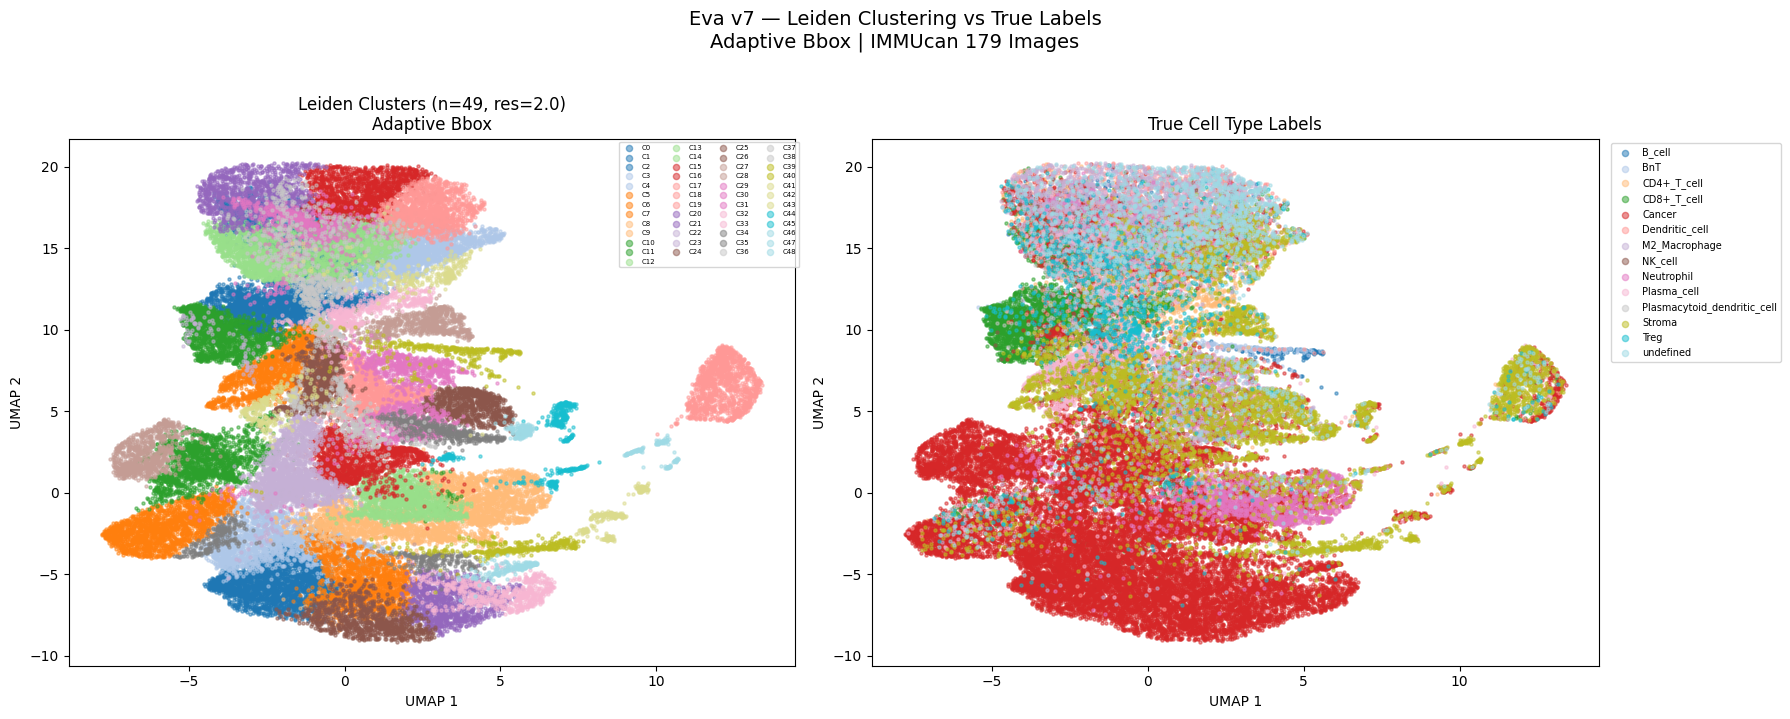

Saved plot_05_leiden_umap.png


In [2]:
import matplotlib.pyplot as plt

n_clusters    = leiden_df['leiden_cluster'].nunique()
unique_labels = sorted(leiden_df['true_label'].unique())
cluster_cmap  = dict(zip(sorted(leiden_df['leiden_cluster'].unique()),
                         plt.cm.tab20(np.linspace(0, 1, n_clusters))))
label_cmap    = dict(zip(unique_labels,
                         plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for cl in sorted(leiden_df['leiden_cluster'].unique()):
    idx = leiden_df['leiden_cluster'] == cl
    ax.scatter(leiden_df.loc[idx, 'umap_1'], leiden_df.loc[idx, 'umap_2'],
               c=[cluster_cmap[cl]], s=5, alpha=0.5, label=f'C{cl}')
ax.set_title(f'Leiden Clusters (n={n_clusters}, res={LEIDEN_RES})\nAdaptive Bbox', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=5, ncol=4, markerscale=2, bbox_to_anchor=(1.01, 1))

ax = axes[1]
for lb in unique_labels:
    idx = leiden_df['true_label'] == lb
    ax.scatter(leiden_df.loc[idx, 'umap_1'], leiden_df.loc[idx, 'umap_2'],
               c=[label_cmap[lb]], s=5, alpha=0.5, label=lb)
ax.set_title('True Cell Type Labels', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.01, 1))

plt.suptitle(f'Eva v7 — Leiden Clustering vs True Labels\nAdaptive Bbox | IMMUcan 179 Images',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_05_leiden_umap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot_05_leiden_umap.png")

Searching for Cluster resolutions

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sys

sys.path.insert(0, '/home/juliaoesterle/.ssh/spCellEval/src/clustering_methods/')
from greedy_f1_utils import greedy_f1_score

OUTPUT_DIR = "/home/juliaoesterle/eva/project/figures/pipeline_v7/"

# Load already-computed neighbours (reuse adata from leiden_clusters_bbox_res2.0.csv)
# We need to rebuild adata from features
all_feats_arr = np.load(OUTPUT_DIR + "all_cell_features_bbox.npy")
metadata_all  = pd.read_csv(OUTPUT_DIR + "all_cell_metadata_bbox.csv")

known_mask = metadata_all['label'] != 'Unknown'
X_known    = all_feats_arr[known_mask.values]
y_known    = metadata_all.loc[known_mask, 'label'].values

adata = sc.AnnData(X=X_known)
adata.obs['true_label'] = pd.Categorical(y_known)

MAX_CELLS = 50000
if len(adata) > MAX_CELLS:
    print(f"Subsampling to {MAX_CELLS:,} cells...")
    sc.pp.subsample(adata, n_obs=MAX_CELLS, random_state=42)

print("Computing neighbours (only needed once)...")
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')

# Target cluster counts
TARGET_CLUSTERS = [70, 100, 120, 140]

def find_resolution(adata, target_n_clusters, res_min=0.1, res_max=20.0, tol=2, max_iter=20):
    """Binary search for resolution that gives ~target_n_clusters"""
    for _ in range(max_iter):
        res_mid = (res_min + res_max) / 2
        sc.tl.leiden(adata, resolution=res_mid, random_state=42,
                     flavor='igraph', n_iterations=2, directed=False)
        n = adata.obs['leiden'].nunique()
        print(f"    res={res_mid:.3f} → {n} clusters (target={target_n_clusters})")
        if abs(n - target_n_clusters) <= tol:
            return res_mid, n
        elif n < target_n_clusters:
            res_min = res_mid
        else:
            res_max = res_mid
    return res_mid, n

# Run for each target
results = []
for target in TARGET_CLUSTERS:
    print(f"\nSearching resolution for ~{target} clusters...")
    res, actual_n = find_resolution(adata, target)
    print(f"  Found: res={res:.3f} → {actual_n} clusters")

    # Greedy F1
    leiden_df = pd.DataFrame({
        'true_label':     adata.obs['true_label'].values,
        'leiden_cluster': adata.obs['leiden'].values,
    })
    gr = greedy_f1_score(leiden_df, 'true_label', 'leiden_cluster', tie_strategy='first')

    results.append({
        'target_clusters': target,
        'actual_clusters': actual_n,
        'resolution':      round(res, 3),
        'accuracy':        gr['accuracy'],
        'f1_macro':        gr['f1_macro'],
        'f1_weighted':     gr['f1_weighted'],
        'ari':             gr['ari'],
        'nmi':             gr['nmi'],
    })
    print(f"  Accuracy={gr['accuracy']:.3f} | Macro F1={gr['f1_macro']:.3f} | ARI={gr['ari']:.3f}")

# Print summary
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_DIR + "leiden_greedy_f1_by_cluster_count.csv", index=False)
print("\n" + "="*60)
print("Summary: Greedy F1 by cluster count")
print("="*60)
print(results_df.to_string(index=False))

Subsampling to 50,000 cells...
Computing neighbours (only needed once)...


/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Searching resolution for ~70 clusters...
    res=10.050 → 179 clusters (target=70)
    res=5.075 → 102 clusters (target=70)
    res=2.587 → 60 clusters (target=70)
    res=3.831 → 81 clusters (target=70)
    res=3.209 → 74 clusters (target=70)
    res=2.898 → 68 clusters (target=70)
  Found: res=2.898 → 68 clusters
  Accuracy=0.593 | Macro F1=0.283 | ARI=0.449

Searching resolution for ~100 clusters...
    res=10.050 → 179 clusters (target=100)
    res=5.075 → 102 clusters (target=100)
  Found: res=5.075 → 102 clusters
  Accuracy=0.598 | Macro F1=0.295 | ARI=0.472

Searching resolution for ~120 clusters...
    res=10.050 → 179 clusters (target=120)
    res=5.075 → 102 clusters (target=120)
    res=7.562 → 145 clusters (target=120)
    res=6.319 → 123 clusters (target=120)
    res=5.697 → 116 clusters (target=120)
    res=6.008 → 116 clusters (target=120)
    res=6.163 → 119 clusters (target=120)
  Found: res=6.163 → 119 clusters
  Accuracy=0.605 | Macro F1=0.319 | ARI=0.478

Searching

Plot: Leiden greedy F1 by cluster count

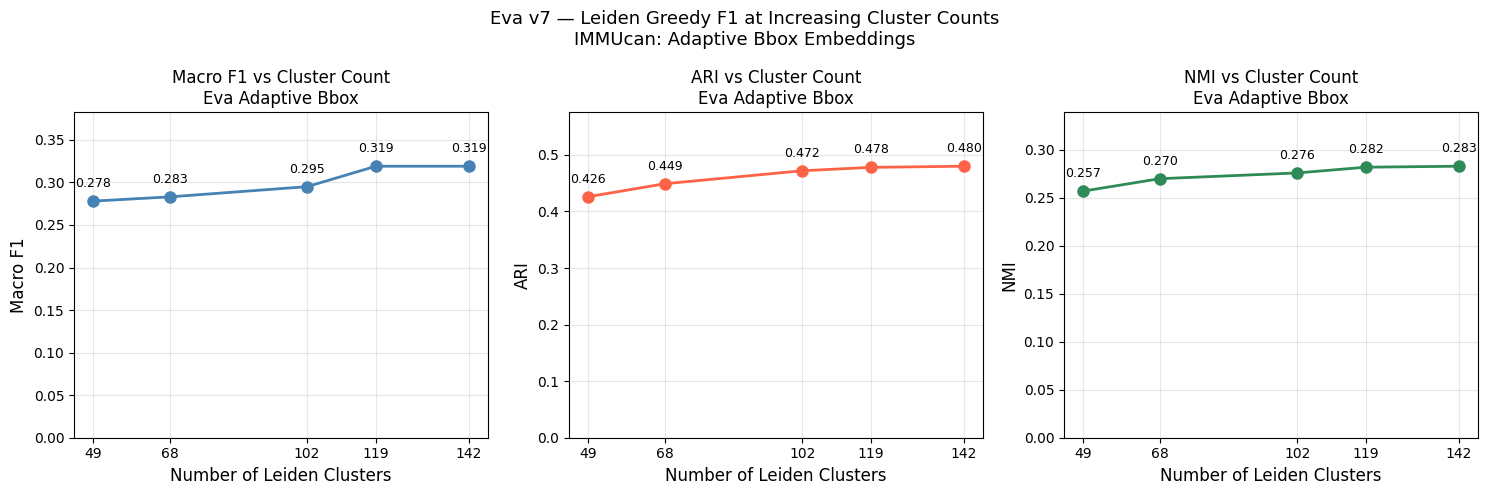

Saved plot_leiden_by_cluster_count.png


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

OUTPUT_DIR = "/home/juliaoesterle/eva/project/figures/pipeline_v7/"

# Data from the run
data = {
    'n_clusters':  [49, 68, 102, 119, 142],   # incl. res=2.0 baseline
    'resolution':  [2.0, 2.898, 5.075, 6.163, 7.252],
    'accuracy':    [0.581, 0.593, 0.598, 0.605, 0.608],
    'f1_macro':    [0.278, 0.283, 0.295, 0.319, 0.319],
    'ari':         [0.426, 0.449, 0.472, 0.478, 0.480],
    'nmi':         [0.257, 0.270, 0.276, 0.282, 0.283],
}
df = pd.DataFrame(data)
df.to_csv(OUTPUT_DIR + "leiden_greedy_f1_by_cluster_count.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('f1_macro',  'Macro F1',  'steelblue'),
    ('ari',       'ARI',       'tomato'),
    ('nmi',       'NMI',       'seagreen'),
]

for ax, (metric, label, color) in zip(axes, metrics):
    ax.plot(df['n_clusters'], df[metric], color=color, linewidth=2,
            marker='o', markersize=8)
    for _, row in df.iterrows():
        ax.annotate(f"{row[metric]:.3f}",
                    (row['n_clusters'], row[metric]),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=9)
    ax.set_xlabel('Number of Leiden Clusters', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} vs Cluster Count\nEva Adaptive Bbox', fontsize=12)
    ax.set_xticks(df['n_clusters'])
    ax.set_xticklabels(df['n_clusters'])
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(df[metric]) * 1.2)

plt.suptitle('Eva v7 — Leiden Greedy F1 at Increasing Cluster Counts\nIMMUcan: Adaptive Bbox Embeddings',
             fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_leiden_by_cluster_count.png", dpi=150)
plt.show()
print("Saved plot_leiden_by_cluster_count.png")

Plot: Learning-Curves (Fold 0, RF at 100 trees)

Test set: 94,678 cells from 36 images
Full train set: 362,439 cells from 143 images

Running learning curve — cells...
      500 cells → Macro F1=0.293
    1,000 cells → Macro F1=0.320
    1,500 cells → Macro F1=0.331
    2,000 cells → Macro F1=0.350
    2,500 cells → Macro F1=0.358
    3,000 cells → Macro F1=0.356
    3,500 cells → Macro F1=0.362
    4,000 cells → Macro F1=0.367
    4,500 cells → Macro F1=0.372
    5,000 cells → Macro F1=0.374
    5,500 cells → Macro F1=0.372
    6,000 cells → Macro F1=0.375
    6,500 cells → Macro F1=0.378
    7,000 cells → Macro F1=0.380
    7,500 cells → Macro F1=0.384
    8,000 cells → Macro F1=0.386
    8,500 cells → Macro F1=0.384
    9,000 cells → Macro F1=0.388
    9,500 cells → Macro F1=0.388
   10,000 cells → Macro F1=0.386
   28,549 cells → Macro F1=0.409
   47,098 cells → Macro F1=0.418
   65,648 cells → Macro F1=0.425
   84,197 cells → Macro F1=0.428
  102,747 cells → Macro F1=0.433
  121,296 cells → Macro F1=0.436
  139,845 cells → Macro

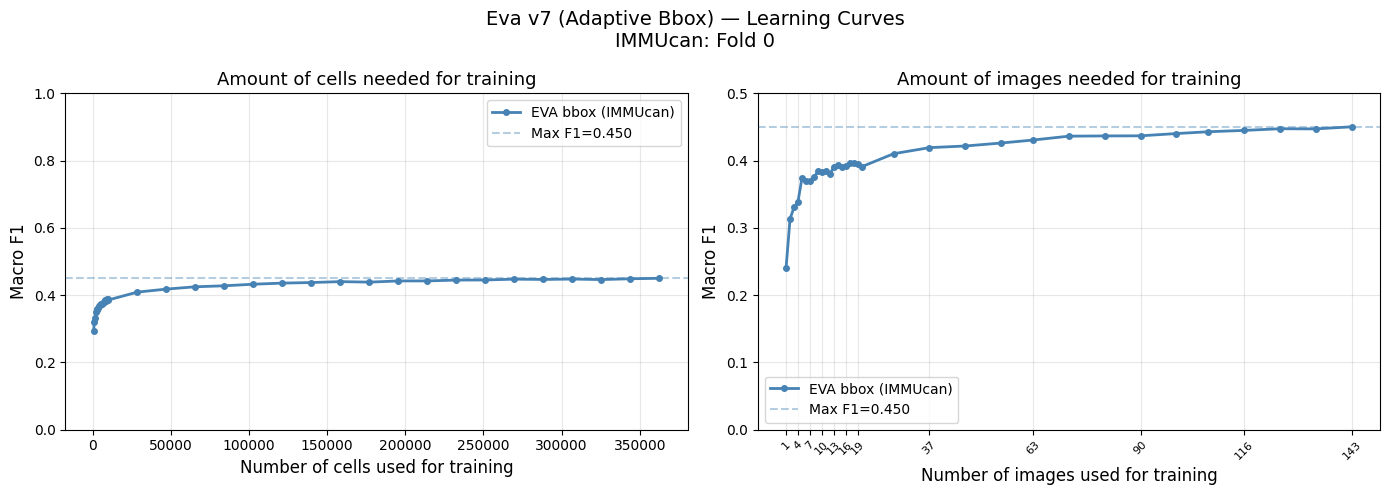

Saved plot_learning_curves.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import json

OUTPUT_DIR = "/home/juliaoesterle/eva/project/figures/pipeline_v7/"
FOLDS_FILE = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/folds.json"

# Load features + metadata
all_feats_arr = np.load(OUTPUT_DIR + "all_cell_features_bbox.npy")
metadata_all  = pd.read_csv(OUTPUT_DIR + "all_cell_metadata_bbox.csv")

with open(FOLDS_FILE) as f:
    folds_data = json.load(f)

# Use Fold 0 only (as Aroj suggested)
FOLD_IDX     = 0
train_images = folds_data[f'fold_{FOLD_IDX}_train_set']  # 143 images
test_images  = folds_data[f'fold_{FOLD_IDX}_test_set']   # 36 images

# Get test set (fixed — never changes)
test_mask  = metadata_all['image_id'].isin(test_images) & (metadata_all['label'] != 'Unknown')
X_test     = all_feats_arr[test_mask.values]
y_test     = metadata_all.loc[test_mask, 'label'].values
print(f"Test set: {len(X_test):,} cells from {len(test_images)} images")

# Get full train set
train_mask   = metadata_all['image_id'].isin(train_images) & (metadata_all['label'] != 'Unknown')
train_meta   = metadata_all[train_mask].reset_index(drop=True)
X_train_full = all_feats_arr[train_mask.values]
y_train_full = metadata_all.loc[train_mask, 'label'].values
print(f"Full train set: {len(X_train_full):,} cells from {len(train_images)} images")

# ── Plot C: #cells vs Macro F1 ────────────────────────────────────────────────
print("\nRunning learning curve — cells...")

# Sample increasing numbers of cells from train set
n_total  = len(X_train_full)
cell_counts = np.unique(np.concatenate([
    np.linspace(500, 10000, 20, dtype=int),
    np.linspace(10000, n_total, 20, dtype=int)
]))
cell_counts = [c for c in cell_counts if c <= n_total]

f1_by_cells = []
for n_cells in cell_counts:
    idx = np.random.RandomState(42).choice(len(X_train_full), n_cells, replace=False)
    X_sub = X_train_full[idx]
    y_sub = y_train_full[idx]
    clf = RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=42, class_weight='balanced'
    )
    clf.fit(X_sub, y_sub)
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_by_cells.append(f1)
    print(f"  {n_cells:>7,} cells → Macro F1={f1:.3f}")

# ── Plot D: #images vs Macro F1 ───────────────────────────────────────────────
print("\nRunning learning curve — images...")

# Use increasing numbers of train images (in order)
image_counts = np.unique(np.concatenate([
    np.arange(1, min(20, len(train_images))+1),
    np.linspace(20, len(train_images), 15, dtype=int)
]))
image_counts = sorted(set([int(i) for i in image_counts if i <= len(train_images)]))

f1_by_images = []
for n_images in image_counts:
    imgs_subset = train_images[:n_images]
    img_mask    = metadata_all['image_id'].isin(imgs_subset) & (metadata_all['label'] != 'Unknown')
    X_sub = all_feats_arr[img_mask.values]
    y_sub = metadata_all.loc[img_mask, 'label'].values
    if len(np.unique(y_sub)) < 2:
        f1_by_images.append(0)
        continue
    clf = RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=42, class_weight='balanced'
    )
    clf.fit(X_sub, y_sub)
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_by_images.append(f1)
    print(f"  {n_images:>3} images → Macro F1={f1:.3f}")

# ── Save results ──────────────────────────────────────────────────────────────
pd.DataFrame({'n_cells': cell_counts, 'macro_f1': f1_by_cells}).to_csv(
    OUTPUT_DIR + "learning_curve_cells.csv", index=False)
pd.DataFrame({'n_images': image_counts, 'macro_f1': f1_by_images}).to_csv(
    OUTPUT_DIR + "learning_curve_images.csv", index=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot C — cells
ax = axes[0]
ax.plot(cell_counts, f1_by_cells, color='steelblue', linewidth=2, marker='o',
        markersize=4, label='EVA bbox (IMMUcan)')
ax.set_xlabel('Number of cells used for training', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Amount of cells needed for training', fontsize=13)
ax.set_ylim(0, 1.0)
ax.axhline(y=max(f1_by_cells), color='steelblue', linestyle='--', alpha=0.4,
           label=f'Max F1={max(f1_by_cells):.3f}')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot D — images
ax = axes[1]
ax.plot(image_counts, f1_by_images, color='steelblue', linewidth=2, marker='o',
        markersize=4, label='EVA bbox (IMMUcan)')
ax.set_xlabel('Number of images used for training', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Amount of images needed for training', fontsize=13)
ax.set_ylim(0, 1)

# Add image count labels on x-axis like in Aroj's figure
step = max(1, len(image_counts) // 10)
ax.set_xticks(image_counts[::step])
ax.set_xticklabels(image_counts[::step], rotation=45, fontsize=8)
ax.axhline(y=max(f1_by_images), color='steelblue', linestyle='--', alpha=0.4,
           label=f'Max F1={max(f1_by_images):.3f}')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Eva v7 (Adaptive Bbox) — Learning Curves\nIMMUcan: Fold 0', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot_learning_curves.png")